# Solve Linear Transport equation with SA PINNs 

In [16]:
import torch 
from torch import nn 
from collections import OrderedDict # To place the hidden layers orderly 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec 
from mpl_toolkits.axes_grid1 import make_axes_locatable 
from utils.SA_PINN_structure import * 
from utils.data import * 
from Linear_Transport_utils import * 

import warnings
warnings.filterwarnings('ignore') # Import the built-in Python warnings module, and tell Python to ignore all warning messages.”
import time 



In [11]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available():
    device = torch.device('cuda') 
else:
    device = torch.device('cpu') 
# 
print(f"Working on {device}") 

Working on mps


# Self-Adaptive Physics-informed Neural Network 

In [12]:
# the physics-informed neural network 
class SA_PINN_Linear_Transport(nn.Module): 
    def __init__(self, X_train, X_init, U_init, t_bc, layers, lb, ub,  wave_speed, N_r = 5000, N_b = 200, N_0 = 100):  
        super().__init__() 
        # boundary conditions: domain bounds 
        self.lb = torch.tensor(lb).float().to(device) 
        self.ub = torch.tensor(ub).float().to(device) 

        # Initial setup    
        self.wave_speed = wave_speed 
        self.N_r = N_r
        self.N_b = N_b
        self.N_0 = N_0 

        # Interior Points 
        self.x = torch.tensor(X_train[:, 0:1], requires_grad = True).float().to(device) # spatial points 
        self.t = torch.tensor(X_train[:, 1:2], requires_grad = True).float().to(device) # temporal points 

        # Initial data 
        self.x_init = torch.tensor(X_init[:]).float().to(device) # initial data points 
        self.t_init = torch.zeros_like(self.x_init).float().to(device) # t = 0 
        self.u_init = torch.tensor(U_init).float().to(device)

        # Boundary data points for periodic boundary conditions 
        self.t_bc = torch.tensor(t_bc).float().to(device) 
        self.x_left = self.lb[0] * torch.ones_like(self.t_bc) 
        self.x_right = self.ub[0] * torch.ones_like(self.t_bc)  
        self.N_bc = self.t_bc.shape[0]

        
        # deep neural network 
        self.dnn = AdaptiveLoss(layers, N_r, N_b, N_0).to(device) 

        
        # optimizers: using the same settings 
        self.optimizer = torch.optim.LBFGS( # requires multiple evaluation of the loss function per iteration 
            self.dnn.layers.parameters(),    # target to be optimized 
            lr = 1.0,    # learning rate: step length 
            max_iter = 1,    # maximum number of iterations 
            max_eval = 500000,    # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-9, 
            line_search_fn = "strong_wolfe" # "strong wolfe condition
        ) 
        
        self.optimizer_Adam = torch.optim.Adam(self.dnn.layers.parameters(), lr = 2e-4, betas = (0.9, 0.999))
        self.optimizer_Adam_r = torch.optim.Adam([self.dnn.lambda_r], lr = 5e-4, betas = (0.9, 0.999))
        self.optimizer_Adam_b = torch.optim.Adam([self.dnn.lambda_b], lr = 5e-4, betas = (0.9, 0.999)) 
        self.optimizer_Adam_0 = torch.optim.Adam([self.dnn.lambda_0], lr = 5e-4, betas = (0.9, 0.999)) 
        # Record the iteration number 
        self.iter = 0 
    
    
    def net_u(self, x, t): # predicted value 
        u = self.dnn(torch.cat([x, t], dim = 1))
        return u

    def PDE_residual(self, x, t): 
        u = self.net_u(x, t) 

        u_x = torch.autograd.grad(
            outputs = u, 
            inputs = x, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True
        )[0] 

        u_t = torch.autograd.grad(
            outputs = u, 
            inputs = t, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True 
        )[0] 
            
        # PDE residual loss 
        f = u_t + self.wave_speed * u_x 
        return f
   
    def loss_func(self, x_init, t_init, u_init, x_int, t_int, x_left, x_right, t_bc, lambda_0, lambda_r, lambda_b):  
        f_pred = self.PDE_residual(x_int, t_int) 
        u0_pred = self.net_u(x_init, t_init) 
        u_left_pred = self.net_u(x_left, t_bc) 
        u_right_pred = self.net_u(x_right, t_bc) 
        
        # mse_r_u = torch.mean(torch.pow(lambda_r * f_pred, 2)) 
        mse_r_u = torch.pow(f_pred, 2) 
        mse_0_u = torch.pow(u0_pred - u_init, 2) 
        mse_b_u_left = torch.pow(u_left_pred, 2) 
        mse_b_u_right = torch.pow(u_right_pred, 2) 
        
       
        lb_detach = lambda_b.detach()
        l0_detach = lambda_0.detach() 
        mse_b = torch.mean(torch.pow(lb_detach[:self.N_bc], 2) * mse_b_u_left) + torch.mean(torch.pow(lb_detach[self.N_bc: 2 * self.N_bc], 2) * mse_b_u_right) 
        mse_b_detach = torch.mean(torch.pow(lambda_b[:self.N_bc], 2) * mse_b_u_left.detach()) + torch.mean(torch.pow(lambda_b[self.N_bc: 2 * self.N_bc], 2) * mse_b_u_right.detach()) 

        mse_0 = torch.mean(torch.pow(l0_detach, 2) * mse_0_u)
        mse_0_detach = torch.mean(torch.pow(lambda_0, 2) * mse_0_u.detach()) 
        
        return (
            
            mse_0 + mse_b + torch.mean(torch.pow(lambda_r.detach(), 2) * mse_r_u),
            mse_0_detach, 
            mse_b_detach, 
            torch.mean(torch.pow(lambda_r, 2) * mse_r_u.detach()),
        )
   
    # For the optimization of LBFGS 
    def closure(self):
        loss_value, mse_0, mse_b, mse_r = self.loss_func(self.x_init, self.t_init, self.u_init, self.x, self.t, self.x_left, self.x_right, self.t_bc, self.dnn.lambda_0, 
                                                         self.dnn.lambda_r, self.dnn.lambda_b) 
        self.optimizer.zero_grad()                             # reset gradients
        loss_value.backward()                                  # compute gradients but only the network weights will be updated 
        return loss_value  
    
    def Optimize(self, Iter1, Iter2): 
        self.dnn.train()
        # Backward and optimize: 2nd phase optimization 
        # Two Phase optimization
        for epoch in range(Iter1):
            loss_value, mse_0, mse_b, mse_r = self.loss_func(self.x_init, self.t_init, self.u_init, self.x, self.t, self.x_left, self.x_right, self.t_bc, self.dnn.lambda_0, 
                                                      self.dnn.lambda_r, self.dnn.lambda_b)  
            # Network parameter update 
            self.optimizer_Adam.zero_grad()
            
            # self.optimizer_Muon.zero_grad()
            loss_value.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 

            self.optimizer_Adam_0.zero_grad() 
            self.optimizer_Adam_r.zero_grad() 
            self.optimizer_Adam_b.zero_grad() 

            (- mse_0).backward() 
            (- mse_b).backward() 
            (- mse_r).backward()

            self.optimizer_Adam_0.step() # only sees the gradient of lambda_0 
            self.optimizer_Adam_b.step() # only sees the gradient of lambda_b  
            self.optimizer_Adam_r.step() # only sees the gradient of lambda_r             
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss_value.item()
                    )
                )

        for i in range(Iter2):  # 2500 × 20 ≈ 50,000 iterations
            self.optimizer.step(self.closure) # Never pass tensors into optimizer.step()
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))

    def predict(self, X):
        x = torch.as_tensor(X[:, 0:1], dtype = torch.float32, device = device) 
        x.requires_grad_(True) 
        t = torch.as_tensor(X[:, 1:2], dtype = torch.float32, device = device) 
        t.requires_grad_(True) 

        self.dnn.eval()
        with torch.no_grad():
            u = self.net_u(x, t) 
        f = self.PDE_residual(x, t)         
        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy() 
        return u, f 

# Configurations 

In [13]:
# Domain bounds 
lb = np.array([-1.0, 0.0]) # second element for time 
ub = np.array([1.0, 1.0]) # second element for time 
length_x = ub[0] - lb[0] 
length_t = ub[1] - lb[1] 
wave_speed = 12 

# Grid point setup 
N_bc = 100
Nx_int = 50 
Nt_int = 100 
N_init = 100  

# Interior part 
X_train_int = interior_points(Nx_int, Nt_int, lb[0], ub[0], lb[1], ub[1])  
print(f"X_train_int shape: {np.shape(X_train_int)}")

# Initial part 
X_train_init = init_points(N_init, lb[0], ub[0]) 
U_train_init = u_0(X_train_init)
print('X_train_init shape: ', np.shape(X_train_init)) 
print('U_train_init shape: ', np.shape(U_train_init)) 

T_bc = bc_points(N_bc, lb[1], ub[1])
print('T_bc shape: ', np.shape(T_bc))  

X_train_int shape: (5000, 2)
X_train_init shape:  (100, 1)
U_train_init shape:  (100, 1)
T_bc shape:  (100, 1)


# Generate Test data and solution  

In [14]:
# Generate test data 
Nx = 200 
Nt = 50
X_test, u_test = test_data(Nx, Nt, lb[0], ub[0], lb[1], ub[1], wave_speed)
print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on non-noisy data 

In [17]:
# chec k!!
noise = 0.0 
N_r = 5000 
N_b = 200 
N_0 = 100 
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 1] 
model = SA_PINN_Linear_Transport(X_train_int, X_train_init, U_train_init, T_bc, layers, lb, ub, wave_speed, N_r, N_b, N_0) 
# training
start = time.time()
model.Optimize(6000, 500)
end = time.time()

It: 0, Loss: 1.464e-01
It: 100, Loss: 1.670e-01
It: 200, Loss: 1.902e-01
It: 300, Loss: 1.805e-01
It: 400, Loss: 9.448e-02
It: 500, Loss: 8.566e-02
It: 600, Loss: 9.310e-02
It: 700, Loss: 1.008e-01
It: 800, Loss: 1.090e-01
It: 900, Loss: 1.180e-01
It: 1000, Loss: 1.277e-01
It: 1100, Loss: 1.382e-01
It: 1200, Loss: 1.494e-01
It: 1300, Loss: 1.614e-01
It: 1400, Loss: 1.742e-01
It: 1500, Loss: 1.875e-01
It: 1600, Loss: 2.006e-01
It: 1700, Loss: 2.128e-01
It: 1800, Loss: 2.269e-01
It: 1900, Loss: 2.434e-01
It: 2000, Loss: 2.609e-01
It: 2100, Loss: 2.792e-01
It: 2200, Loss: 2.983e-01
It: 2300, Loss: 3.182e-01
It: 2400, Loss: 3.388e-01
It: 2500, Loss: 3.601e-01
It: 2600, Loss: 3.822e-01
It: 2700, Loss: 4.050e-01
It: 2800, Loss: 4.284e-01
It: 2900, Loss: 4.525e-01
It: 3000, Loss: 4.772e-01
It: 3100, Loss: 5.025e-01
It: 3200, Loss: 5.285e-01
It: 3300, Loss: 5.551e-01
It: 3400, Loss: 5.819e-01
It: 3500, Loss: 6.094e-01
It: 3600, Loss: 6.373e-01
It: 3700, Loss: 6.655e-01
It: 3800, Loss: 6.936e-0

In [19]:
# evaluations 
u_pred, f_pred = model.predict(X_test) 
print(f"u_pred shape: {np.shape(u_pred)}") 
print(f"f_pred shape: {np.shape(f_pred)}") 


error_u = np.linalg.norm(u_test - u_pred, 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
error_f = np.linalg.norm(f_pred, ord = np.inf) 

print('Error u: %e' % (error_u)) 
print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end-start:.2f} seconds')

u_pred shape: (10000, 1)
f_pred shape: (10000, 1)
Error u: 9.594025e-01
PDE loss: 6.473282e+00
Training time is 157.13 seconds


In [22]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
wave_speed = 12 
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 1] 

# Grid point setup 
N_bc = 100
Nx_int = 50 
Nt_int = 100 
N_init = 100  
N_r = 5000 
N_b = 200 
N_0 = 100 

# Training points 
training_sets = np.load(
    "Linear_Transport_training_points_5000_sets.npy",
    allow_pickle=True
)

for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_init = data["X_train_init"] 
    U_train_init = u_0(X_train_init)
    T_bc = data["T_bc"]
    model = SA_PINN_Linear_Transport(X_train_int, X_train_init, U_train_init, T_bc, layers, lb, ub, wave_speed, N_r, N_b, N_0) 
    start = time.time() 
    model.Optimize(6000, 500) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) 
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 2.024e-01
It: 100, Loss: 1.954e-01
It: 200, Loss: 2.276e-01
It: 300, Loss: 2.640e-01
It: 400, Loss: 3.039e-01
It: 500, Loss: 3.433e-01
It: 600, Loss: 7.596e-02
It: 700, Loss: 8.150e-02
It: 800, Loss: 8.290e-02
It: 900, Loss: 5.968e-02
It: 1000, Loss: 5.186e-02
It: 1100, Loss: 5.501e-02
It: 1200, Loss: 5.815e-02
It: 1300, Loss: 6.133e-02
It: 1400, Loss: 6.496e-02
It: 1500, Loss: 6.898e-02
It: 1600, Loss: 7.342e-02
It: 1700, Loss: 7.771e-02
It: 1800, Loss: 8.234e-02
It: 1900, Loss: 8.714e-02
It: 2000, Loss: 9.218e-02
It: 2100, Loss: 9.748e-02
It: 2200, Loss: 1.029e-01
It: 2300, Loss: 1.086e-01
It: 2400, Loss: 1.144e-01
It: 2500, Loss: 1.204e-01
It: 2600, Loss: 1.263e-01
It: 2700, Loss: 1.307e-01
It: 2800, Loss: 1.322e-01
It: 2900, Loss: 1.375e-01
It: 3000, Loss: 1.464e-01
It: 3100, Loss: 1.511e-01
It: 3200, Loss: 1.580e-01
It: 3300, Loss: 1.656e-01
It: 3400, Loss: 1.749e-01
It: 3500, Loss: 1.816e-01
It: 3600, Loss: 1.913e-01
It: 3700, Loss: 1.982e-01
It: 3800, Loss: 2.083e-0

In [23]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

err_l2 mean:  0.9602983864779461
0.004887585236909523
err_linf mean:  1.23296664655757
0.43293554385630223
Training time mean:  151.8580462217331
14.57802357637576


In [24]:
# Save the results 
results = {
    "Model": "SA_PINN",
    "num_features": layers, 
    "Training_points_int_bc": [Nx, Nt, N_bc], 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Linear_Transport_SA_PINN_5000_training_points_data.pt")

# Visualization 

' \nfig.subplots_adjust(\n    wspace=0.08,\n    bottom=0.25\n)\n'

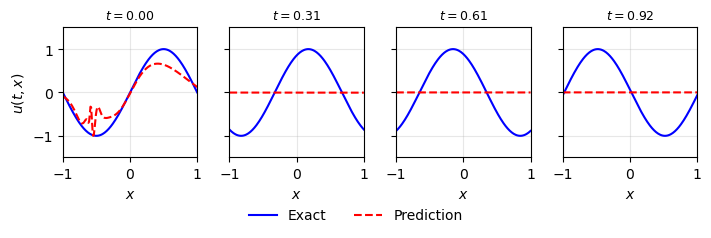

In [20]:
import matplotlib.gridspec as gridspec 

fig, axes = plt.subplots(
    1, 4,
    figsize=(7, 2),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.1}
)
# fig.subplots_adjust(wspace=0.1)

times = [0, 15, 30, 45]

for ax, idx in zip(axes, times):
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_test[idx*Nx:(idx+1)*Nx],
        'b-',
        linewidth=1.5,
        label='Exact'
    )
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_pred[idx*Nx:(idx+1)*Nx,0],
        'r--',
        linewidth=1.5,
        label='Prediction'
    )

    ax.set_title(
        rf'$t={X_test[idx * Nx, 1]:.2f}$',
        fontsize=9
    )

    ax.set_xlim([-1,1])
    ax.set_ylim([-1.5,1.5])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$u(t,x)$')
for ax in axes:
    ax.set_xlabel(r'$x$')
""" 
axes[1].legend(
    loc='lower center',
    bbox_to_anchor=(0.5,-0.75),
    ncol=2,
    frameon=False
)
"""
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)
)
""" 
fig.subplots_adjust(
    wspace=0.08,
    bottom=0.25
)
""" 
# fig.savefig("Linear_Transport_SA_PINN.png", dpi=300, bbox_inches='tight')
